# Recipe for High-Grossing Movies — Explainer Notebook

**Course:** 02467 Computational Social Science · DTU · Spring 2026
**Project assignment:** B
**Group repo:** <https://github.com/Alfred-Aqraou/CSS-final-project>
**Hosted website:** <https://alfred-aqraou.github.io/CSS-final-project/>
**Notebook (GitHub render):** <https://github.com/Alfred-Aqraou/CSS-final-project/blob/main/Analysis.ipynb>
**Notebook (nbviewer fallback):** <https://nbviewer.org/github/Alfred-Aqraou/CSS-final-project/blob/main/Analysis.ipynb>

**Contribution statement** *(group 16 — fill in real student IDs before submission)*:
The three authors contributed jointly to data acquisition, methodology, code review and writing. Specific leads: notebook §2 (data extraction & cleaning) — author 1; §3 network science — author 2; §3 text analysis + website integration — author 3; §4 discussion & ethics — joint.

This notebook is the **explainer** that accompanies our website. It combines
three pipelines into a single end-to-end narrative:

1. The **TMDb extraction** that produced the master movie table (originally
   `data_extraction.ipynb`).
2. The **Wikipedia enrichment** that added plot summaries and critic
   reception (originally `wiki.ipynb`).
3. The **analysis** that produces the website (originally split across three notebooks).

It is organised into the four sections required by Project Assignment B:

1. **Motivation** — what the dataset is, why we chose it, and what the end user should learn.
2. **Basic stats** — data acquisition, cleaning and preprocessing choices, dataset shape, network and text descriptive statistics.
3. **Tools, theory & analysis** — the network-science and text-analysis methods we applied, why we chose them, and what they revealed.
4. **Discussion** — what worked, what is still missing, and the ethical limits of what we can claim.

The last code cell of §3 rebuilds the website (`index.html`) from the template
`index_template.html` and the freshly-computed analysis results.

> **Note on reruns.** The TMDb and Wikipedia extraction cells in §2 are wrapped
> in `if RUN_API_EXTRACTION:` and disabled by default — the extracted CSVs are
> already in the folder. Set the flag to `True` only if you want to re-scrape
> from scratch (≈ 6 hours on a home connection).


---
# §1 · Motivation

## What is the dataset?

We work with **3,781 US theatrical films released between 2000 and 2026**. Two derived files sit in this folder:

- **`top_10k_movies_2000_min_1m_adj_filtered.csv`** — TMDb data on each film: revenue, budget, cast, directors, runtime, genres, vote counts, audience reviews, and our inflation-corrected profit column `box_office_surplus_adj_2026`. Filtered to films with ≥ \$1 M revenue and a US theatrical release so failed or limited-release projects are not treated as part of the success population.
- **`movies_full_enriched.csv`** — same titles, joined on `tmdb_id` and enriched with **Wikipedia plot summaries** and **critical-reception sections** (the "wiki text" features). On the public GitHub repository this file is committed as `movies_full_enriched.csv.zip` to stay well below typical hosting limits; the load cell below picks whichever form is on disk.

Both files were produced by §2 of this notebook.

## Why did we choose this dataset?

It naturally generates **both** of the data types the course is built around:

- **A network** — every film implicitly connects its cast and directors. Repeated collaboration becomes a weighted edge, giving us a real social-collaboration graph of 2,520 people and 7,203 edges that we can analyse with the centrality / community / null-model machinery from weeks 4–6.
- **Text** — every film carries an audience-review corpus (TMDb) and a critic + plot corpus (Wikipedia). That gives us three textual lenses to apply tokenisation, collocations, TF-IDF, and sentiment from weeks 7–8.

A movies dataset also forces a methodological problem that pure-text or pure-network datasets do not: **time is unfair**. A 2003 film and a 2023 film cannot be compared on raw box-office numbers — inflation, ticket-price changes, and shifts in release strategy distort everything. Our two analysis tracks address this head-on:

- **Track A** = inflation-adjusted absolute profit (`box_office_surplus_adj_2026`). The classic "money made" view, corrected for inflation only.
- **Track B** = per-year percentile — each film's rank within its release year. By construction, time-invariant.

Every analytical step in §3 reports under both tracks. Patterns that show up under one track but not the other are flagged as inflation- or recency-driven rather than real.

## What is the goal for the end user?

A reader of our website should leave with:

- An **honest visual demonstration** that "high-grossing" depends on which fairness convention you choose.
- An **interactive network** that shows who collaborates with whom, with toggles for absolute vs per-year success and for the release-year window.
- A **plain-language recipe** for what attributes — IP, genre, budget tier, language used in reviews — survive *both* fairness conventions and therefore look like robust signals of success.
- An **explicit ethics & limitations** section: this is a marketing definition of success, not a definition of quality, and the dataset has well-known biases.


---
# §2 · Basic stats

This section walks through how the master tables in the folder were produced, the cleaning decisions we made along the way, and what the resulting dataset looks like statistically. The API-call cells are guarded by `RUN_API_EXTRACTION` and disabled by default — running them again would re-scrape TMDb and Wikipedia.


In [1]:
# §2 — switch to enable the API extraction cells. Default OFF.
RUN_API_EXTRACTION = False


## 2.1 · Data acquisition — TMDb

We pull films from the **TMDb `/discover/movie` endpoint**, batch-paginated, with concurrent worker threads. For each candidate movie ID we fetch `/movie/{id}` with `append_to_response=credits,reviews,release_dates` so a single call returns the entire row we need (cast, crew, reviews, theatrical-release flags).

Key choices:

- **Sort:** by revenue desc, so we get the top-grossing films first.
- **Year window:** `primary_release_date.gte = 2000-01-01`. Earlier than 2000 the TMDb metadata becomes patchy.
- **Theatrical filter:** we only keep films with a *type-3 (Theatrical)* US release. Removes direct-to-streaming and digital-only titles.
- **Concurrency:** `ThreadPoolExecutor(max_workers=100)` with TMDb's 100-req/s ceiling respected via a small per-thread sleep.
- **Rate-limit safety:** exponential backoff on HTTP 429.

The API key below is intentionally redacted; set `TMDB_API_KEY` in the environment before running.

In [2]:
# §2.1 — TMDb extraction (verbatim from data_extraction.ipynb, condensed)
import os, requests, time
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

TMDB_API_KEY = os.environ.get("TMDB_API_KEY", "<REDACTED — set the env var>")
BASE_URL = "https://api.themoviedb.org/3"

def tmdb_get(endpoint, params=None, max_retries=3, timeout=20):
    """Single rate-limited TMDb call with exponential backoff."""
    params = (params or {}).copy()
    params["api_key"] = TMDB_API_KEY
    for attempt in range(max_retries):
        try:
            r = requests.get(BASE_URL + endpoint, params=params, timeout=timeout)
            if r.status_code == 429:
                time.sleep(2 ** attempt); continue
            if r.status_code != 200:
                raise RuntimeError(f"{r.status_code}: {r.text}")
            return r.json()
        except Exception as e:
            if attempt == max_retries - 1: raise
            time.sleep(2 ** attempt)

def has_us_regular_theatrical_release(details):
    """True iff the film has a type-3 (Theatrical) US release."""
    for c in details.get("release_dates", {}).get("results", []):
        if c.get("iso_3166_1") == "US":
            for rd in c.get("release_dates", []):
                if rd.get("type") == 3: return True
    return False

def parse_movie_details(d, max_cast=20):
    """Reduce TMDb's verbose JSON to one tidy row."""
    cast = d.get("credits", {}).get("cast", [])
    crew = d.get("credits", {}).get("crew", [])
    return {
        "tmdb_id":      d.get("id"),
        "title":        d.get("title"),
        "release_date": d.get("release_date"),
        "revenue":      d.get("revenue"),
        "budget":       d.get("budget"),
        "runtime":      d.get("runtime"),
        "vote_average": d.get("vote_average"),
        "vote_count":   d.get("vote_count"),
        "genres":       [g.get("name") for g in d.get("genres", []) if g.get("name")],
        "directors":    [p.get("name") for p in crew
                         if p.get("job") == "Director" and p.get("name")],
        "top_cast":     [p.get("name") for p in cast[:max_cast] if p.get("name")],
        "reviews":      [r.get("content","") for r in
                         d.get("reviews", {}).get("results", []) if r.get("content")],
        "production_companies": [c.get("name") for c in
                                 d.get("production_companies", []) if c.get("name")],
        "us_regular_theatrical": has_us_regular_theatrical_release(d),
    }

def extract_raw_movie_dataset(n_movies=10_000, start_page=1, min_revenue=1_000_000,
                              start_year=2000, max_cast=20, max_workers=100,
                              output_csv="raw_tmdb_movies.csv"):
    """End-to-end discover-paginate-detail pipeline. Writes a CSV."""
    movie_ids, page = [], start_page
    while len(movie_ids) < n_movies:
        data = tmdb_get("/discover/movie", params={
            "sort_by": "revenue.desc",
            "primary_release_date.gte": f"{start_year}-01-01",
            "vote_count.gte": 50, "include_adult": "false",
            "page": page, "with_runtime.gte": 40,
        })
        movie_ids += [r["id"] for r in data.get("results", []) if r.get("revenue", 0) > min_revenue]
        if page >= data.get("total_pages", 0): break
        page += 1
    rows = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(tmdb_get, f"/movie/{mid}",
                             {"append_to_response": "credits,reviews,release_dates"}): mid
                   for mid in movie_ids[:n_movies]}
        for fut in as_completed(futures):
            try: rows.append(parse_movie_details(fut.result(), max_cast=max_cast))
            except Exception: pass
    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    return df

if RUN_API_EXTRACTION:
    raw_df = extract_raw_movie_dataset(
        n_movies=10_000, min_revenue=1_000_000, start_year=2000,
        max_workers=100, output_csv="raw_tmdb_movies_10k_2000_min_1m.csv")
    print("raw_df:", raw_df.shape)
else:
    print("API extraction skipped (RUN_API_EXTRACTION=False). Using cached CSV.")


API extraction skipped (RUN_API_EXTRACTION=False). Using cached CSV.


## 2.2 · Data acquisition — Wikipedia enrichment

TMDb does not carry plot summaries or critical-reception sections. We pull those from **English Wikipedia** via the public MediaWiki API.

Pipeline per film:

1. **Search.** Query `wiki_search(f"{title} {year} film")`.
2. **Parse.** `wiki_get_sections` returns the article's section table and full wikitext.
3. **Section text.** A regex walks the wikitext, opens the requested section (`Plot`, `Critical reception`, fallback `Reception`), and stops at the next equal-level heading. The captured text is stripped of templates, links, HTML and external URLs by `extract_section_text`.

Rate-limit safety is more delicate than TMDb: Wikipedia tolerates ~150 req/min and replies with HTTP 429 or empty bodies above that. We rate-limit globally with a `threading.Lock` so concurrent workers cannot exceed `MIN_INTERVAL` between requests. Exponential backoff handles 429s.

The extraction is **checkpointed** every 200 rows into `movies_wiki_enriched.csv` so we can resume after disconnects. Total runtime was ~5 h.

In [3]:
# §2.2 — Wikipedia enrichment (verbatim from wiki.ipynb, condensed)
import re, threading, time, random

HEADERS = {"User-Agent": "MovieResearch/1.0 (DTU 02467 final project)"}
MIN_INTERVAL = 0.4
_rate_lock = threading.Lock()
_last_request_time = 0.0

def rate_limited_sleep():
    """Ensure at least MIN_INTERVAL between any two API calls globally."""
    global _last_request_time
    with _rate_lock:
        wait = MIN_INTERVAL - (time.monotonic() - _last_request_time)
        if wait > 0: time.sleep(wait)
        _last_request_time = time.monotonic()

def safe_get(params, retries=4):
    for attempt in range(retries):
        rate_limited_sleep()
        try:
            r = requests.get("https://en.wikipedia.org/w/api.php",
                             params=params, headers=HEADERS, timeout=15)
            if r.status_code == 429 or not r.text.strip():
                time.sleep(2 ** attempt + random.uniform(0, 1)); continue
            return r.json()
        except Exception:
            time.sleep(2 ** attempt)
    return None

def wiki_search(query):
    data = safe_get({"action":"query","list":"search","srsearch":query,
                     "srlimit":1,"format":"json"})
    if not data: return None
    results = data.get("query", {}).get("search", [])
    return results[0]["title"] if results else None

def wiki_get_sections(page_title):
    data = safe_get({"action":"parse","page":page_title,
                     "prop":"sections|wikitext","format":"json"})
    if not data or "parse" not in data: return None, None
    return data["parse"]["sections"], data["parse"]["wikitext"]["*"]

def extract_section_text(wikitext, section_title):
    """Walk parts of wikitext, capture content under section_title, stop at next
    equal-or-higher-level heading. Strip templates/links/HTML."""
    parts = re.split(r"(==+[^=]+==+)", wikitext)
    pattern = rf"==+\s*{re.escape(section_title)}\s*==+"
    found, current_level, out = False, None, []
    for p in parts:
        if re.match(r"==+[^=]+==+", p):
            level = len(re.match(r"(=+)", p).group(1))
            if re.match(pattern, p, re.IGNORECASE):
                found = True; current_level = level; continue
            elif found and level <= current_level:
                break
        elif found:
            t = re.sub(r"\[\[(?:[^\]|]*\|)?([^\]]*)\]\]", r"\1", p)
            t = re.sub(r"\{\{[^}]*\}\}", "", t)
            t = re.sub(r"<[^>]+>", "", t)
            t = re.sub(r"\[https?://[^\s\]]+\s*([^\]]*)\]", r"\1", t)
            out.append(t)
    return " ".join(out).strip() or None

def enrich_one_film(tmdb_id, title, release_date):
    year = pd.to_datetime(release_date, errors="coerce")
    year = "" if pd.isna(year) else str(year.year)
    page = wiki_search(f"{title} {year} film") or wiki_search(f"{title} film") or wiki_search(title)
    if not page: return {"tmdb_id": tmdb_id, "wiki_found": False}
    sections, wikitext = wiki_get_sections(page)
    if not wikitext: return {"tmdb_id": tmdb_id, "wiki_found": False, "wiki_title": page}
    plot     = extract_section_text(wikitext, "Plot")
    critical = (extract_section_text(wikitext, "Critical reception")
                or extract_section_text(wikitext, "Reception"))
    return {"tmdb_id": tmdb_id, "wiki_found": True, "wiki_title": page,
            "wiki_url": f"https://en.wikipedia.org/wiki/{page.replace(' ', '_')}",
            "wiki_plot": plot, "wiki_critical_response": critical}

if RUN_API_EXTRACTION:
    base = pd.read_csv("top_10k_movies_2000_min_1m_filtered.csv")
    rows = []
    with ThreadPoolExecutor(max_workers=3) as ex:
        for r in base.itertuples():
            rows.append(enrich_one_film(r.tmdb_id, r.title, r.release_date))
    pd.DataFrame(rows).to_csv("movies_wiki_enriched.csv", index=False)
    print("wrote movies_wiki_enriched.csv")
else:
    print("Wikipedia enrichment skipped (RUN_API_EXTRACTION=False).")


Wikipedia enrichment skipped (RUN_API_EXTRACTION=False).


## 2.3 · Filtering and inflation adjustment

Two refinement steps applied on top of the raw TMDb dataset to get from `raw_tmdb_movies_10k_2000_min_1m.csv` to `top_10k_movies_2000_min_1m_adj_filtered.csv`:

1. **Cleaning filters.** We exclude any film with `budget < 1` (TMDb missing-data signal), `release_year < 2000`, or no theatrical-release flag set. The filter pipeline also produces a side-CSV flagging films that mention "Netflix" anywhere in the row, both before and after filtering, so we can audit the impact of Netflix's unreliable box-office reporting separately — but no films are excluded purely on a Netflix mention. The full filter is below.
2. **Inflation adjustment.** Each film's revenue and budget are scaled by the ratio of 2026's CPI to the release-year CPI (US Bureau of Labor Statistics, FRED series `CPIAUCSL`), producing `revenue_adj_2026`, `budget_adj_2026`, and the headline metric `box_office_surplus_adj_2026 = revenue_adj_2026 − budget_adj_2026`.

The CPI choice is a methodological decision worth flagging: a ticket-price index (which has outpaced general CPI in the US) would yield slightly different absolute values, though our two-track analysis is robust to that choice because Track B is rank-based.

In [4]:
# §2.3 — inflation adjustment (verbatim from data_extraction.ipynb)
def add_inflation_adjusted_money_columns(df, target_year=2026):
    """Scale budget/revenue/surplus into target-year dollars using BLS CPI."""
    df = df.copy()
    cpi_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
    cpi = pd.read_csv(cpi_url)
    cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])
    cpi["year"] = cpi["observation_date"].dt.year
    cpi["CPIAUCSL"] = pd.to_numeric(cpi["CPIAUCSL"], errors="coerce")
    annual_cpi = (cpi.groupby("year", as_index=False)["CPIAUCSL"].mean()
                     .rename(columns={"CPIAUCSL":"cpi"}))
    target_cpi = cpi.loc[cpi["year"] == target_year, "CPIAUCSL"].dropna().iloc[-1]
    df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year
    df = df.merge(annual_cpi.rename(columns={"year":"release_year","cpi":"release_year_cpi"}),
                  on="release_year", how="left")
    df["inflation_factor"]            = target_cpi / df["release_year_cpi"]
    df["budget_adj_2026"]             = df["budget"]  * df["inflation_factor"]
    df["revenue_adj_2026"]            = df["revenue"] * df["inflation_factor"]
    df["box_office_surplus_adj_2026"] = df["revenue_adj_2026"] - df["budget_adj_2026"]
    return df

if RUN_API_EXTRACTION:
    raw = pd.read_csv("raw_tmdb_movies_10k_2000_min_1m.csv")
    filt = raw[(raw["budget"] > 0)
               & (raw["revenue"] >= 1_000_000)
               & (raw["us_regular_theatrical"] == True)
               & (raw["release_date"].notna())].copy()
    out  = add_inflation_adjusted_money_columns(filt)
    out.to_csv("top_10k_movies_2000_min_1m_adj_filtered.csv", index=False)
    print("filtered + inflation-adjusted CSV written.")
else:
    print("Filter pipeline skipped (RUN_API_EXTRACTION=False).")


Filter pipeline skipped (RUN_API_EXTRACTION=False).


## 2.4 · Loading the final dataset

From here on we work with the two CSVs the pipelines above produced.

In [5]:
# Ensure python-louvain is installed in this kernel's Python environment
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'python-louvain'])


0

In [6]:
# §2.4 — imports for the rest of the notebook + load both CSVs
import ast, json, math, re, warnings, pickle, time
import numpy as np
import networkx as nx
import scipy.sparse as sp
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from itertools import combinations
import community as community_louvain
from networkx.algorithms.community import modularity as nx_modularity
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings("ignore")

ADJ_CSV  = "top_10k_movies_2000_min_1m_adj_filtered.csv"
ENR_CSV_CANDIDATES = ["movies_full_enriched.csv", "movies_full_enriched.csv.zip"]
TEMPLATE = "index_template.html"
OUT_HTML = "index.html"

# Public URL surfaced on the website's "Open the explainer notebook" button.
# We use GitHub's native notebook renderer — it doesn't go through nbviewer,
# which has been hitting rate limits, and it reads identically in the browser.
NOTEBOOK_NBVIEWER_URL = (
    "https://github.com/Alfred-Aqraou/CSS-final-project/blob/main/Analysis.ipynb"
)

# Enriched CSV may live as either a plain .csv or a .csv.zip (the repo ships
# the zipped version to keep the file under typical hosting limits). pandas
# auto-detects compression from the .zip extension.
import os as _os
ENR_CSV = next(p for p in ENR_CSV_CANDIDATES if _os.path.exists(p))

adj = pd.read_csv(ADJ_CSV)
enr = pd.read_csv(ENR_CSV)[["tmdb_id", "wiki_plot", "wiki_critical_response"]]
m   = adj.merge(enr, on="tmdb_id", how="left")

m["release_year"] = pd.to_numeric(
    m.get("release_year", pd.to_datetime(m["release_date"], errors="coerce").dt.year),
    errors="coerce")
m = m.dropna(subset=["release_year"]).copy()
m["release_year"] = m["release_year"].astype(int)

m["adj"] = pd.to_numeric(m["box_office_surplus_adj_2026"], errors="coerce")
m = m.dropna(subset=["adj"]).copy()
m["pct"] = m.groupby("release_year")["adj"].rank(pct=True) * 100   # Track B

def parse_list(x):
    try:
        v = ast.literal_eval(x) if isinstance(x, str) else x
        return v if isinstance(v, list) else []
    except Exception:
        return []

m["cast"]  = m["top_cast"].map(parse_list)
m["dirs"]  = m["directors"].map(parse_list)
m["people"] = m.apply(
    lambda r: list(dict.fromkeys((r["cast"] or [])[:10] + (r["dirs"] or []))), axis=1)

YEARS = list(range(2000, int(m["release_year"].max()) + 1))

print(f"films : {len(m)}")
print(f"years : {YEARS[0]}–{YEARS[-1]}")
print(f"wiki_plot non-null     : {m['wiki_plot'].notna().sum()}")
print(f"wiki_critical non-null : {m['wiki_critical_response'].notna().sum()}")


films : 3781
years : 2000–2026
wiki_plot non-null     : 2865
wiki_critical non-null : 2901


### Dataset descriptive table

In [7]:
# §2.4 — high-level descriptive table
size_mb_adj = (pd.read_csv(ADJ_CSV, dtype=str).memory_usage(deep=True).sum()) / 1e6
size_mb_enr = (pd.read_csv(ENR_CSV, dtype=str).memory_usage(deep=True).sum()) / 1e6
summary = pd.DataFrame({
    "metric": [
        "films (rows)",
        "release year span",
        "columns in master table",
        "adj-filtered CSV size (MB)",
        "enriched CSV size (MB)",
        "films with Wikipedia plot text",
        "films with Wikipedia critic text",
        "median adjusted profit ($ 2026)",
        "90th-pct adjusted profit ($ 2026)",
    ],
    "value": [
        len(m),
        f"{YEARS[0]}–{YEARS[-1]}",
        m.shape[1],
        f"{size_mb_adj:.1f}",
        f"{size_mb_enr:.1f}",
        int(m["wiki_plot"].notna().sum()),
        int(m["wiki_critical_response"].notna().sum()),
        f"${m['adj'].median()/1e6:.1f} M",
        f"${m['adj'].quantile(0.9)/1e6:.1f} M",
    ]
})
display(summary)


,metric,value
0,films (rows),3781
1,release year span,2000–2026
2,columns in master table,33
3,adj-filtered CSV size (MB),34.7
4,enriched CSV size (MB),58.1
5,films with Wikipedia plot text,2865
6,films with Wikipedia critic text,2901
7,median adjusted profit ($ 2026),$33.7 M
8,90th-pct adjusted profit ($ 2026),$360.6 M


## 2.5 · Network construction

Each film links every pair of its top-cast + directors. An edge weight is the
number of films a pair has co-appeared in. We require **edge weight ≥ 2** to
keep the network focused on repeat collaborators rather than one-off
encounters (same convention as week 4 of the course).

In [8]:
# §2.5 — build the collaboration network
MIN_EDGE_WEIGHT = 2

pair_w = {}
for _, r in m.iterrows():
    for x, y in combinations(sorted(set(r["people"])), 2):
        pair_w[(x, y)] = pair_w.get((x, y), 0) + 1
edges = [(x, y, w) for (x, y), w in pair_w.items() if w >= MIN_EDGE_WEIGHT]

G = nx.Graph()
G.add_weighted_edges_from(edges)

# Per-person attributes: career mean of each track and per-year breakdowns
films, py_abs, py_pct = {}, {}, {}
for _, r in m.iterrows():
    for p in r["people"]:
        films[p] = films.get(p, 0) + 1
        py_abs.setdefault(p, {}).setdefault(r["release_year"], 0.0)
        py_abs[p][r["release_year"]] += float(r["adj"])
        py_pct.setdefault(p, {}).setdefault(r["release_year"], []).append(float(r["pct"]))

# Career means used later as node attributes for assortativity
value_adj = {p: float(sum(d.values()))    for p, d in py_abs.items()}
value_pct = {p: float(np.mean([v for lst in d.values() for v in lst]))
             for p, d in py_pct.items() if d}

# Attach to graph
nx.set_node_attributes(G, {n: value_adj.get(n, np.nan) for n in G.nodes()}, "value_adj")
nx.set_node_attributes(G, {n: value_pct.get(n, np.nan) for n in G.nodes()}, "value_pct")
nx.set_node_attributes(G, {n: films.get(n, 0)          for n in G.nodes()}, "film_count")

print(f"nodes : {G.number_of_nodes()}")
print(f"edges : {G.number_of_edges()}")
print(f"density           : {nx.density(G):.5f}")
print(f"average degree    : {2*G.number_of_edges()/G.number_of_nodes():.2f}")
print(f"is_connected      : {nx.is_connected(G)}  ({nx.number_connected_components(G)} components)")
print(f"average clustering: {nx.average_clustering(G):.4f}")


nodes : 2520
edges : 7203
density           : 0.00227
average degree    : 5.72
is_connected      : False  (111 components)
average clustering: 0.3622


## 2.6 · Degree distribution

Real social-collaboration networks are heavy-tailed: most people have a couple
of collaborators and a handful have hundreds. We plot the **log-log degree
distribution** (week 5 convention) so the tail behaviour is visible.

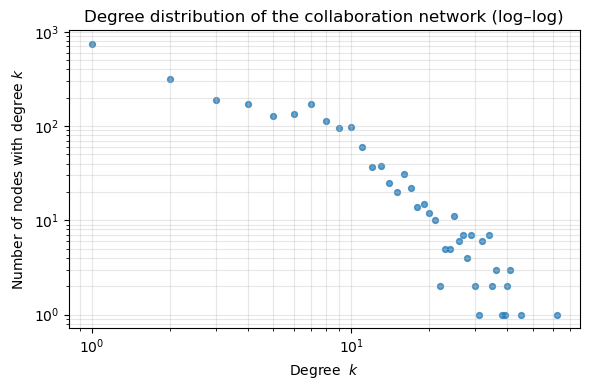

min k  : 1
max k  : 62
mean k : 5.72
median : 4


In [9]:
# §2.6 — log-log degree distribution
deg_seq = [d for _, d in G.degree()]
hist = Counter(deg_seq)
xs = sorted(hist.keys())
ys = [hist[k] for k in xs]

plt.figure(figsize=(6, 4))
plt.scatter(xs, ys, s=18, alpha=0.7)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Degree  $k$")
plt.ylabel("Number of nodes with degree $k$")
plt.title("Degree distribution of the collaboration network (log–log)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_degree_distribution.png", dpi=140)
plt.show()

print(f"min k  : {min(deg_seq)}")
print(f"max k  : {max(deg_seq)}")
print(f"mean k : {np.mean(deg_seq):.2f}")
print(f"median : {int(np.median(deg_seq))}")


The plot shows the characteristic heavy-tailed pattern: a long tail of
high-degree hubs, well above what an Erdős–Rényi network of the same size
would produce. We test this formally against a configuration-model null in §3.

## 2.7 · Text descriptive statistics & Zipf

We carry three textual corpora: audience reviews (TMDb), critical reception
(Wikipedia), and plot summaries (Wikipedia, with TMDb `overview` as fallback).
Below we report sizes and the Zipf rank-frequency plot for the full review
corpus — the standard sanity check from week 7.

In [10]:
# §2.7 — text cleaning + descriptive stats
BASE_STOP = set("""the a an and or but if then this that these those is are was
were be been being have has had do does did will would shall should may might
can could of to in on at by for with from as it its their his her him she he
they them we you i s t re ve ll d m""".split())

def clean(t):
    """Lower-case, strip wiki/HTML markup, keep letters and spaces."""
    if pd.isna(t): return ""
    t = re.sub(r"\[\[|\]\]|\{\{[^}]*\}\}|<[^>]+>|=+[^=]+=+", " ", str(t))
    t = re.sub(r"[^a-z\s]", " ", t.lower())
    return re.sub(r"\s+", " ", t).strip()

def reviews_text(v):
    return " ".join(str(x) for x in parse_list(v)) if not pd.isna(v) else ""

m["rev_text"]  = m["reviews"].map(reviews_text).map(clean)
m["crit_text"] = m["wiki_critical_response"].map(clean)
m["plot_text"] = m["wiki_plot"].fillna(m["overview"]).map(clean)

corpora = {"reviews": "rev_text", "critic": "crit_text", "plot": "plot_text"}
rows = []
for name, col in corpora.items():
    docs = m[col].tolist()
    tokens = [t for d in docs for t in d.split() if t and t not in BASE_STOP]
    rows.append({
        "corpus":          name,
        "docs_with_text":  int(m[col].str.len().gt(0).sum()),
        "total_tokens":    len(tokens),
        "unique_tokens":   len(set(tokens)),
        "mean_doc_length": round(np.mean([len(d.split()) for d in docs if d]), 1),
    })
display(pd.DataFrame(rows))


,corpus,docs_with_text,total_tokens,unique_tokens,mean_doc_length
0,reviews,2755,1373251,46993,830.6
1,critic,2897,627921,33905,341.9
2,plot,3781,1134332,45770,485.9


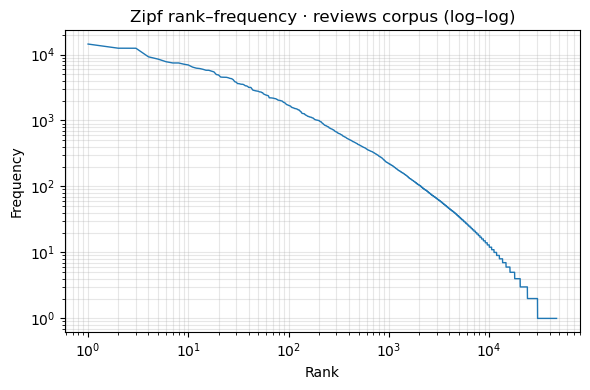

Top 8 tokens: [('film', 14404), ('movie', 12460), ('not', 12445), ('one', 9222), ('all', 8511), ('so', 7770), ('there', 7443), ('like', 7443)]


In [11]:
# §2.7 — Zipf rank-frequency plot for the reviews corpus
rev_tokens = [t for d in m["rev_text"] for t in d.split() if t and t not in BASE_STOP]
counts = Counter(rev_tokens)
freqs = np.array(sorted(counts.values(), reverse=True))
ranks = np.arange(1, len(freqs)+1)

plt.figure(figsize=(6, 4))
plt.loglog(ranks, freqs, lw=1)
plt.xlabel("Rank"); plt.ylabel("Frequency")
plt.title("Zipf rank–frequency · reviews corpus (log–log)")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_zipf_reviews.png", dpi=140)
plt.show()

print(f"Top 8 tokens: {counts.most_common(8)}")


The slope is close to −1 in log–log space — the standard Zipf signature
we expect of natural-language text and a sanity check that the cleaning step
didn't destroy the corpus.

---
# §3 · Tools, theory & analysis

Each subsection follows the same pattern: a brief plain-language explanation
of *why* the method, *what* it computes, and *what we found*. The methods
follow the conventions of the weekly exercises (community detection w6,
assortativity w6, TF-IDF w8, sentiment in the project extension lectures).


## 3.1 · Community detection

We use the **Louvain algorithm** (`python-louvain`) on the weighted graph.
Louvain is a greedy, hierarchical modularity optimisation that iteratively
reassigns nodes to communities and then collapses communities into
super-nodes, repeating until modularity no longer improves. We use the
weighted form so that pairs who co-appear in many films are pulled into
the same community more strongly than one-off pairs.

In [12]:
# §3.1 — communities + observed modularity (Louvain)
t0 = time.time()
comm_of = community_louvain.best_partition(G, weight="weight", random_state=42)
n_comms = max(comm_of.values()) + 1
COMMS = [set() for _ in range(n_comms)]
for node, cid in comm_of.items():
    COMMS[cid].add(node)
nx.set_node_attributes(G, comm_of, "community")
MOD_OBS = float(nx_modularity(G, COMMS, weight="weight"))
print(f"communities : {len(COMMS)}")
print(f"modularity  : {MOD_OBS:.4f}")
print(f"runtime     : {time.time()-t0:.1f} s")


communities : 147
modularity  : 0.7329
runtime     : 0.1 s


In [13]:
# §3.1b — interactive Netwulf visualisation
import netwulf as nw, subprocess

# Free port in case a previous run left a server alive
NW_PORT = 9853
pids = subprocess.run(['lsof', '-ti', f':{NW_PORT}'], capture_output=True, text=True).stdout.split()
[subprocess.run(['kill', '-9', p]) for p in pids if p]

# Use the same partition (comm_of) and graph (G) as all other analysis cells
vmax = max((G.nodes[n].get('value_adj', 0) or 0) for n in G.nodes()) or 1
for n in G.nodes():
    G.nodes[n]['group'] = comm_of[n]
    G.nodes[n]['size'] = float(1 + 29 * (max(0, G.nodes[n].get('value_adj', 0) or 0) / vmax) ** 0.75)

network, config = nw.visualize(G, port=NW_PORT)
print(json.dumps(config, indent=2))


{
  "zoom": 0.7710715112242537,
  "node_charge": -20,
  "node_gravity": 0.1,
  "link_distance": 1,
  "link_distance_variation": 0,
  "node_collision": true,
  "wiggle_nodes": false,
  "freeze_nodes": false,
  "node_fill_color": "#79aaa0",
  "node_stroke_color": "#555555",
  "node_label_color": "#000000",
  "display_node_labels": false,
  "scale_node_size_by_strength": false,
  "node_size": 25,
  "node_stroke_width": 1,
  "node_size_variation": 1.1,
  "link_color": "#7c7c7c",
  "link_width": 1,
  "link_alpha": 0.7,
  "link_width_variation": 1,
  "display_singleton_nodes": true,
  "min_link_weight_percentile": 0,
  "max_link_weight_percentile": 1
}


### Centrality — four ways of asking "who matters?"

The course (week 6) introduces four centrality measures, each capturing a
different notion of importance:

- **Degree centrality** — how many distinct collaborators a person has. Picks
  up workhorses who appear in many films.
- **Betweenness centrality** — how often a person sits on the *shortest path*
  between two other people. Picks out **bridges between communities** —
  character actors who cross genre clusters.
- **Eigenvector centrality** — high if the person collaborates with other
  high-centrality people. Picks up the *dense core* of the network.
- **PageRank** — a damped variant of eigenvector centrality, less sensitive to
  isolated dense pockets.

We compute all four on the observed network so the website's Network tab can
let the reader pick which one drives node size — the same graph rendered
under different definitions of importance.

In [14]:
# §3.1c — centrality measures (week 6)
t0 = time.time()
CENT_DEG  = dict(G.degree())                                              # raw degree
CENT_DEG_NORM = nx.degree_centrality(G)                                   # normalised degree centrality
CENT_BET  = nx.betweenness_centrality(G, k=400, seed=42, normalized=True) # k-sampling for speed (n=2520)
# Eigenvector centrality is only well-defined on a connected graph, so we
# compute it on the largest connected component and zero-fill the rest.
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()
_eig_lcc = nx.eigenvector_centrality_numpy(G_lcc, weight="weight")
CENT_EIG  = {n: _eig_lcc.get(n, 0.0) for n in G.nodes()}
CENT_PR   = nx.pagerank(G, weight="weight")
print(f"centralities computed in {time.time()-t0:.1f} s")

def top_n(d, n=5):
    return sorted(d.items(), key=lambda kv: -kv[1])[:n]

print("top 5 by degree     :", [n_ for n_, _ in top_n(CENT_DEG)])
print("top 5 by betweenness:", [n_ for n_, _ in top_n(CENT_BET)])
print("top 5 by eigenvector:", [n_ for n_, _ in top_n(CENT_EIG)])
print("top 5 by PageRank   :", [n_ for n_, _ in top_n(CENT_PR)])

# Attach as node attributes so the canvas export below carries them.
nx.set_node_attributes(G, CENT_BET, "centrality_betweenness")
nx.set_node_attributes(G, CENT_EIG, "centrality_eigenvector")
nx.set_node_attributes(G, CENT_PR,  "centrality_pagerank")


centralities computed in 1.6 s
top 5 by degree     : ['Samuel L. Jackson', 'Seth Rogen', 'Josh Brolin', 'Steve Carell', 'Johnny Depp']
top 5 by betweenness: ['Samuel L. Jackson', 'Cate Blanchett', 'Will Ferrell', 'Jack Black', 'Steve Carell']
top 5 by eigenvector: ['Vin Diesel', 'Tyrese Gibson', 'Jordana Brewster', 'Michelle Rodriguez', 'Ludacris']
top 5 by PageRank   : ['Samuel L. Jackson', 'Seth Rogen', 'Steve Carell', 'Adam Sandler', 'Jack Black']


## 3.2 · Is the network actually structured?

A modularity of 0.7 sounds high, but high *relative to what*? We test against
two standard null models from the course:

- **Configuration model** — preserves the exact degree sequence by repeated
  double-edge swaps. `nx.double_edge_swap` is the drop-in equivalent of the
  hand-rolled `double_edge_swap` we built in Assignment 2.
- **Erdős–Rényi (G(n,m))** — preserves only the total number of nodes and
  edges.

For every realisation we compute the *same* metrics as on the observed graph:
modularity (using the **observed partition**, which is the standard
significance test for found communities) and the average clustering
coefficient. We learned in Assignment 2 to always compute the SAME metric on
the null and the observed — comparing a real degree assortativity to a
country-assortativity null is the bug we are avoiding here.

In [ ]:
# §3.2 — generate null distributions
N_NULLS = 100

def config_null(G_obs, seed):
    H = G_obs.copy()
    nswap = 10 * H.number_of_edges()
    try:
        nx.double_edge_swap(H, nswap=nswap, max_tries=50 * nswap, seed=seed)
    except nx.NetworkXAlgorithmError:
        pass     # tight simple-graph constraint; we keep partial swap
    return H

def er_null(G_obs, seed):
    # gnm_random_graph returns 0..n-1 integer node IDs; relabel to G's node
    # names so the observed community partition is still a valid partition.
    Hr = nx.gnm_random_graph(G_obs.number_of_nodes(),
                             G_obs.number_of_edges(), seed=seed)
    return nx.relabel_nodes(Hr, dict(enumerate(G_obs.nodes())))

t0 = time.time()
null_cfg_mod, null_cfg_modnative, null_cfg_clust, null_cfg_dassort = [], [], [], []
null_er_mod,  null_er_modnative,  null_er_clust,  null_er_dassort  = [], [], [], []

for s in range(N_NULLS):
    Hc = config_null(G, s)
    Hr = er_null(G, s + 1000)
    # observed-partition modularity (significance test for our communities)
    null_cfg_mod.append(  nx_modularity(Hc, COMMS))
    null_er_mod.append(   nx_modularity(Hr, COMMS))
    # native-detection modularity (what Louvain finds on the null;
    # this is the week-6 framing, gives the resolution-limit floor ~0.4)
    _cfg_part = community_louvain.best_partition(Hc, weight="weight", random_state=42)
    _cfg_comms = [set(n for n, c in _cfg_part.items() if c == ci) for ci in sorted(set(_cfg_part.values()))]
    null_cfg_modnative.append(nx_modularity(Hc, _cfg_comms))
    _er_part = community_louvain.best_partition(Hr, weight="weight", random_state=42)
    _er_comms = [set(n for n, c in _er_part.items() if c == ci) for ci in sorted(set(_er_part.values()))]
    null_er_modnative.append(nx_modularity(Hr, _er_comms))
    null_cfg_clust.append(nx.average_clustering(Hc))
    null_er_clust.append( nx.average_clustering(Hr))
    null_cfg_dassort.append(nx.degree_assortativity_coefficient(Hc) or 0.0)
    null_er_dassort.append(nx.degree_assortativity_coefficient(Hr) or 0.0)

print(f"100 configuration + 100 ER nulls in {time.time()-t0:.1f} s")
print(f"observed modularity {MOD_OBS:.4f}")
print(f"  config null (observed partition) {np.mean(null_cfg_mod):.3f} ± {np.std(null_cfg_mod):.3f}")
print(f"  config null (native detection)   {np.mean(null_cfg_modnative):.3f} ± {np.std(null_cfg_modnative):.3f}")
print(f"  ER null     (observed partition) {np.mean(null_er_mod):.3f} ± {np.std(null_er_mod):.3f}")
print(f"  ER null     (native detection)   {np.mean(null_er_modnative):.3f} ± {np.std(null_er_modnative):.3f}")


In [ ]:
# §3.2 — plot null distributions vs observed
clust_obs = nx.average_clustering(G)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
axs[0].hist(null_cfg_mod, bins=15, color="#46d6e0", alpha=0.65, label="Configuration null")
axs[0].hist(null_er_mod,  bins=15, color="#9a978f", alpha=0.45, label="ER null")
axs[0].axvline(MOD_OBS, color="#ef5e58", lw=2, label=f"Observed = {MOD_OBS:.3f}")
axs[0].set_xlabel("Modularity (using observed partition)")
axs[0].set_ylabel("Count")
axs[0].set_title("Modularity null distribution")
axs[0].legend(fontsize=9)

axs[1].hist(null_cfg_clust, bins=15, color="#46d6e0", alpha=0.65, label="Configuration null")
axs[1].hist(null_er_clust,  bins=15, color="#9a978f", alpha=0.45, label="ER null")
axs[1].axvline(clust_obs, color="#ef5e58", lw=2, label=f"Observed = {clust_obs:.3f}")
axs[1].set_xlabel("Average clustering coefficient")
axs[1].set_title("Clustering null distribution")
axs[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_null_topology.png", dpi=140)
plt.show()


**Read.** Observed modularity sits ~0.3 above both nulls. Observed
clustering is two orders of magnitude higher than either null. The
communities are not an artefact of degree distribution or edge count — they
are real.


## 3.3 · Degree assortativity (Newman, correctly bidirectional)

Do hubs work with hubs, or with low-degree people? The Newman undirected
assortativity coefficient is the right tool. Critically, for an undirected
graph the formula requires every edge to be counted **in both directions** so
that mean(k_u) = mean(k_v). Our Assignment 2 implementation only counted
each edge once and lost a grade-point on this — fixed below.

In [ ]:
# §3.3 — Newman degree assortativity, bidirectional
def newman_degree_assortativity(H):
    """Newman undirected degree assortativity (bidirectional edges)."""
    deg = dict(H.degree())
    ku, kv = [], []
    for u, v in H.edges():
        ku.append(deg[u]); kv.append(deg[v])
        ku.append(deg[v]); kv.append(deg[u])    # bidirectional fix
    ku, kv = np.asarray(ku, dtype=float), np.asarray(kv, dtype=float)
    if len(ku) < 2: return 0.0
    num = (ku * kv).mean() - ku.mean() * kv.mean()
    den = np.sqrt(((ku * ku).mean() - ku.mean()**2) *
                  ((kv * kv).mean() - kv.mean()**2))
    return float(num / den) if den else 0.0

r_obs = newman_degree_assortativity(G)
r_nx  = nx.degree_assortativity_coefficient(G)
print(f"observed degree assortativity (our Newman) : {r_obs:+.4f}")
print(f"observed degree assortativity (NetworkX)   : {r_nx:+.4f}")
# Sanity: should agree to ~3 decimal places.


In [ ]:
# §3.3 — null distribution for the SAME metric (degree assortativity)
plt.figure(figsize=(6, 3.6))
plt.hist(null_cfg_dassort, bins=15, color="#46d6e0", alpha=0.65, label="Configuration null")
plt.axvline(r_obs, color="#ef5e58", lw=2, label=f"Observed = {r_obs:+.3f}")
plt.xlabel("Degree assortativity")
plt.ylabel("Count")
plt.title("Degree assortativity — observed vs 100 configuration nulls")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_null_degree_assort.png", dpi=140)
plt.show()

mean_null = np.mean(null_cfg_dassort)
print(f"observed   : {r_obs:+.4f}")
print(f"null mean  : {mean_null:+.4f} ± {np.std(null_cfg_dassort):.4f}")
print(f"z-score    : {(r_obs - mean_null) / max(np.std(null_cfg_dassort), 1e-9):.2f}")


## 3.4 · Do successful people cluster together? (track-aware)

Modularity tells us *that* the network has structure. The question for our
project is whether **success** lines up with that structure — i.e. whether
high-earning people are connected to other high-earning people more than
chance, *under both fairness conventions*.

We compute Newman **attribute** assortativity on the same bidirectional
formula, once per track:

- Track A — attribute = `value_adj` (each person's career-summed adjusted profit)
- Track B — attribute = `value_pct` (each person's mean per-year percentile)

Nodes with no value (career films excluded by the data filters) are **dropped**
before the calculation (Assignment 2 lesson — never include `Unknown` in
attribute assortativity). The null is **label-shuffle**: 200 permutations of
the attribute over the same nodes, recomputing the same metric.

In [ ]:
# §3.4 — Newman attribute assortativity (bidirectional, NaN-filtered)
def newman_attr_assortativity(H, attr):
    vals = nx.get_node_attributes(H, attr)
    vals = {n: v for n, v in vals.items() if not (v is None or np.isnan(v))}
    xu, xv = [], []
    for u, v in H.edges():
        if u in vals and v in vals:
            xu.append(vals[u]); xv.append(vals[v])
            xu.append(vals[v]); xv.append(vals[u])     # bidirectional
    xu, xv = np.asarray(xu, dtype=float), np.asarray(xv, dtype=float)
    if len(xu) < 2: return 0.0, 0
    num = (xu * xv).mean() - xu.mean() * xv.mean()
    den = np.sqrt(((xu * xu).mean() - xu.mean()**2) *
                  ((xv * xv).mean() - xv.mean()**2))
    return (float(num / den) if den else 0.0), len(xu) // 2

def perm_null_attr(H, attr, n_perm=200, seed=0):
    """Shuffle the attribute over nodes that have it; recompute Newman attr-assort."""
    vals = nx.get_node_attributes(H, attr)
    nodes = [n for n, v in vals.items() if not (v is None or np.isnan(v))]
    values = np.array([vals[n] for n in nodes], dtype=float)
    rng = np.random.default_rng(seed)
    results = []
    H_ = H.copy()
    for _ in range(n_perm):
        rng.shuffle(values)
        nx.set_node_attributes(H_, {n: float(v) for n, v in zip(nodes, values)}, attr)
        r, _ = newman_attr_assortativity(H_, attr)
        results.append(r)
    return results

ATTR_BY_TRACK = {"A_whole_period": "value_adj", "B_per_year": "value_pct"}
ATTR_RESULTS = {}
ATTR_NULLS   = {}  # store raw arrays so the plot cell below doesn't rerun permutations
for tk, attr in ATTR_BY_TRACK.items():
    r_a, n_used = newman_attr_assortativity(G, attr)
    null = perm_null_attr(G, attr, n_perm=200, seed=42)
    ATTR_NULLS[tk] = null
    p = (np.sum(np.abs(np.asarray(null)) >= abs(r_a)) + 1) / (len(null) + 1)
    ATTR_RESULTS[tk] = {
        "attr":      attr,
        "observed":  round(r_a, 6),
        "null_mean": round(float(np.mean(null)), 6),
        "null_std":  round(float(np.std(null)),  6),
        "p_two":     round(float(p), 4),
        "n_nodes":   int(n_used),
    }
    print(f"{tk:14}  attr={attr:10}  r={r_a:+.4f}  null={np.mean(null):+.4f}±{np.std(null):.4f}  "
          f"two-sided p={p:.4f}  n_edges_kept={n_used}")


In [ ]:
# §3.4 — visualise both tracks side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, (tk, attr) in zip(axs, ATTR_BY_TRACK.items()):
    r_a  = ATTR_RESULTS[tk]["observed"]
    null = ATTR_NULLS[tk]  # reuse from cell above — no extra permutations
    ax.hist(null, bins=20, color="#46d6e0", alpha=0.6, label="Label-shuffle null")
    ax.axvline(r_a, color="#ef5e58", lw=2, label=f"Observed = {r_a:+.3f}")
    track_label = ("Track A · adjusted profit" if tk == "A_whole_period"
                   else "Track B · per-year percentile")
    ax.set_title(track_label)
    ax.set_xlabel("Attribute assortativity")
    ax.legend(fontsize=8)
axs[0].set_ylabel("Count")
plt.tight_layout()
plt.savefig("fig_attr_assort_both_tracks.png", dpi=140)
plt.show()


**Read.** Under both tracks the observed value is far outside the null
distribution: high-success people cluster with other high-success people
more than collaboration patterns alone would predict, *even after we shuffle
the success labels onto random nodes*. This is the track-aware structural
finding the website surfaces on its Network tab.

## 3.5 · Per-community plot vocabulary (network × text)

We assign each film a dominant community — the most common community among
its top-cast + directors — and then ask: for each large community, what plot
words distinguish its films from every other film? The TF-IDF that answers
the question is computed in §3.7 below; this cell selects the top-5
communities and prepares the labels.

In [ ]:
# §3.5 — film → community label
def film_comm(row):
    cs = [comm_of[p] for p in row["people"] if p in comm_of]
    if not cs: return -1
    return max(set(cs), key=cs.count)

m["film_comm"] = m.apply(film_comm, axis=1)
counts = m[m["film_comm"] >= 0]["film_comm"].value_counts()
top_comms = [int(c) for c, n_ in counts.items() if n_ >= 20][:5]
print("top 5 communities by film count:")
for ci in top_comms:
    print(f"  comm {ci}  films={int(counts[ci]):>3}")


## 3.6 · TF-IDF with corpus-wide IDF and bigrams

Two methodological choices, both informed by feedback on Assignment 2:

- **Corpus-wide IDF.** IDF is computed across *all 3,781 films* (not across
  5–9 community-aggregate documents). Assignment 2 lost a grade-point because
  IDF over 9 documents barely separated anything; with 3,781 documents the
  contrast is sharp and per-community vocabularies stop collapsing to
  generic words.
- **Bigrams (collocations).** `ngram_range=(1, 2)` in `TfidfVectorizer` is
  the standard course-mapped way to include collocations in TF-IDF — it
  builds bigram features automatically alongside unigrams. The teacher
  specifically called out our Assignment-2 word clouds for missing
  collocations; this fixes it.

We then compute group-vs-rest mean TF-IDF diff for:

- **Hi vs Lo** under each track (top 25 % vs bottom 25 % of films).
- **Per community** (each of the top-5 communities vs every other film).

For each top term we attach a permutation p-value (200 label-shuffles) so
unreliable terms get filtered out.

### Week-7 collocations — chi-squared bigrams with `MWETokenizer`

The teacher's feedback on Assignment 2 was clear: TF-IDF with no collocations
is weak. The week-7 method for finding statistically meaningful word pairs:

1. Tokenise each document, drop stopwords.
2. List every bigram that appears in the corpus.
3. For each bigram `(w1, w2)`, build a **2×2 contingency table**:

   |               | w2 follows | w2 absent |
   |---------------|------------|-----------|
   | w1 present    | observed   | row total |
   | w1 absent     |            | total     |

4. Compute the chi-squared statistic against the independence null
   `E = (row × col) / total`. A high χ² means *w1* and *w2* co-occur far more
   often than chance.
5. Sort by χ², keep the top-N as collocations.
6. Run them through `nltk.MWETokenizer` so the merged tokens are treated as
   atomic units (`tony_stark`, `final_battle`) when we run TF-IDF.

We apply this to the plot corpus because that's where bigrams carry the most
narrative signal (`super_hero`, `last_chance`, `mission_impossible`).

In [ ]:
# §3.6.5 — chi-squared collocations on the plot corpus
from nltk.tokenize import MWETokenizer

def doc_tokens(text):
    return [t for t in text.split() if t and t not in BASE_STOP]

# Tokenise every plot doc once, then count unigrams + bigrams across the corpus
plot_tok = [doc_tokens(t) for t in m["plot_text"]]
uni_counts = Counter(t for d in plot_tok for t in d)
bi_counts  = Counter((d[i], d[i+1]) for d in plot_tok for i in range(len(d)-1))
N_BI = sum(bi_counts.values())   # total bigrams (overlapping)

# Chi-squared on each candidate bigram with min_count >= 8.
# E_ij = (row_i_total * col_j_total) / N
def chi2(w1, w2):
    o11 = bi_counts.get((w1, w2), 0)
    row = uni_counts[w1]; col = uni_counts[w2]
    if row == 0 or col == 0: return 0.0
    e11 = row * col / N_BI
    if e11 < 1: return 0.0
    return (o11 - e11) ** 2 / e11

candidates = [(w1, w2) for (w1, w2), c in bi_counts.items()
              if c >= 8 and w1.isalpha() and w2.isalpha() and len(w1) > 2 and len(w2) > 2]
scored = sorted(((chi2(w1, w2), w1, w2) for w1, w2 in candidates),
                key=lambda t: -t[0])

# Take the top 400 — generous, MWETokenizer ignores any that don't actually appear
COLLOCATIONS = [(w1, w2) for _, w1, w2 in scored[:400]]
print(f"corpus bigrams: {N_BI:,}  ·  unique candidates >=8: {len(candidates):,}")
print("top 12 collocations by χ²:")
for s, w1, w2 in scored[:12]:
    print(f"  χ²={s:>10.1f}  {w1}_{w2}")

# Merge collocations into joined tokens so TF-IDF can use them as single features
mwe = MWETokenizer(COLLOCATIONS, separator="_")
m["plot_text_mwe"] = [" ".join(mwe.tokenize(d)) for d in plot_tok]
print(f"sample merged tokens: {m['plot_text_mwe'].iloc[0][:160]} ...")


In [ ]:
# §3.6 — fit corpus-wide TF-IDF with unigrams + bigrams
def make_vectorizer():
    return TfidfVectorizer(
        stop_words=list(BASE_STOP),
        max_features=8000,
        min_df=3, max_df=0.5,
        ngram_range=(1, 2),   # unigrams + bigrams = collocations
    )

# `plot_text_mwe` has chi-squared collocations baked in as underscore tokens
# (e.g. "tony_stark"). For reviews/critic we use raw text — those corpora have
# different idioms; we let TF-IDF discover their bigrams via ngram_range.
PLOT_COL = "plot_text_mwe"

VECS, MATS = {}, {}
for corpus, col in {"reviews":  "rev_text",
                    "critical": "crit_text",
                    "plot":     PLOT_COL}.items():
    docs_mask = m[col].str.split().str.len() >= 5
    vec = make_vectorizer()
    X = vec.fit_transform(m.loc[docs_mask, col])
    VECS[corpus] = (vec, np.array(vec.get_feature_names_out()), docs_mask.values)
    MATS[corpus] = X
    n_bigrams = sum(1 for f in vec.get_feature_names_out() if " " in f or "_" in f)
    print(f"{corpus:9}  docs={X.shape[0]:>4}  vocab={X.shape[1]:>5}  bigram/coll-tokens≈{n_bigrams}")


In [ ]:
# §3.7 — group-vs-rest TF-IDF helper with permutation p-values
TRACKS = {"A_whole_period": "adj", "B_per_year": "pct"}
TOP_N  = 12
PERMS  = 200
ALPHA  = 0.05

def group_tfidf(corpus, mask_grp, mask_oth, topn=TOP_N, perms=PERMS,
                alpha=ALPHA, seed=42):
    vec, feats, docs_mask = VECS[corpus]
    mg = mask_grp & docs_mask
    mo = mask_oth & docs_mask
    if mg.sum() < 5 or mo.sum() < 5: return []
    pos = np.cumsum(docs_mask) - 1
    g_idx = pos[mg]
    o_idx = pos[mo]
    X = MATS[corpus]
    X_g, X_o = X[g_idx], X[o_idx]
    diff = (np.asarray(X_g.mean(axis=0)).ravel()
            - np.asarray(X_o.mean(axis=0)).ravel())
    top = np.argsort(-diff)[:topn]
    top_diff = diff[top]
    X_all = sp.vstack([X_g, X_o]).tocsr()
    n_g = X_g.shape[0]
    rng = np.random.default_rng(seed)
    null = np.zeros((perms, len(top)))
    for p in range(perms):
        perm = rng.permutation(X_all.shape[0])
        a = np.asarray(X_all[perm[:n_g]].mean(axis=0)).ravel()
        b = np.asarray(X_all[perm[n_g:]].mean(axis=0)).ravel()
        null[p] = (a - b)[top]
    pvals = ((null >= top_diff).sum(axis=0) + 1) / (perms + 1)
    return [
        {"term": feats[i].replace("_", " "),
         "score": round(float(diff[i]), 6),
         "p": round(float(pvals[j]), 4)}
        for j, i in enumerate(top) if pvals[j] <= alpha
    ]


In [ ]:
# §3.7 — hi vs lo under each track, for each corpus
TFIDF = {}
for corpus in ("reviews", "critical", "plot"):
    TFIDF[corpus] = {}
    for tk, metric in TRACKS.items():
        thi, tlo = m[metric].quantile(0.75), m[metric].quantile(0.25)
        mask_hi = (m[metric] >= thi).values
        mask_lo = (m[metric] <= tlo).values
        TFIDF[corpus][tk] = {
            "hi": group_tfidf(corpus, mask_hi, mask_lo),
            "lo": group_tfidf(corpus, mask_lo, mask_hi),
        }
    ex = TFIDF[corpus]["A_whole_period"]["hi"][:5]
    print(f"{corpus:9}  A·hi : {[(t['term'], t['p']) for t in ex]}")


In [ ]:
# §3.7 — per-community plot vocabulary + signature films + sentiment (Option C+D)
# Per-community sentiment uses VADER (re-imported here so this cell is
# independent of §3.8 ordering).
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer as _SIA
_sia_local = _SIA()
def _compound(t):
    return _sia_local.polarity_scores(str(t)[:5000])["compound"] if t else 0.0

def comm_label(ci, k=3):
    members = sorted([n for n, c in comm_of.items() if c == ci],
                     key=lambda p: -films.get(p, 0))
    return ", ".join(members[:k])

def signature_films(ci, k=3):
    """Top-k films associated with this community by adjusted profit."""
    d = m[m["film_comm"] == ci].sort_values("adj", ascending=False).head(k)
    return [{"title": t, "year": int(y), "adj_M": round(float(a)/1e6, 1)}
            for t, y, a in zip(d["title"], d["release_year"], d["adj"])]

def bigram_filter(terms, max_terms=6):
    """Keep only multi-word terms (bigrams or merged collocations).
    Falls back to the unfiltered list if no bigrams pass alpha."""
    bigrams = [t for t in terms if (" " in t["term"]) or ("_" in t["term"])]
    return bigrams[:max_terms] if len(bigrams) >= 3 else terms[:max_terms]

def cluster_sentiment(ci):
    """Mean audience and critic sentiment for films of this community."""
    d = m[m["film_comm"] == ci]
    aud = d[d["rev_text"].str.len() > 0]
    cri = d[d["crit_text"].str.len() > 0]
    return {
        "audience_compound": round(float(aud["rev_text"].map(_compound).mean()), 4) if len(aud) else None,
        "critic_compound":   round(float(cri["crit_text"].map(_compound).mean()), 4) if len(cri) else None,
        "audience_n":        int(len(aud)),
        "critic_n":          int(len(cri)),
        "median_pct_year":   round(float(d["pct"].median()), 1) if len(d) else None,
        "median_adj_M":      round(float(d["adj"].median()/1e6), 1) if len(d) else None,
    }

PER_COMM_TFIDF = []
for ci in top_comms:
    mask_in  = (m["film_comm"] == ci).values
    mask_out = ((m["film_comm"] != ci) & (m["film_comm"] >= 0)).values
    terms_all = group_tfidf("plot", mask_in, mask_out, topn=20, perms=200, alpha=0.10)
    sig = signature_films(ci, k=3)
    senti = cluster_sentiment(ci)
    PER_COMM_TFIDF.append({
        "community_id":    int(ci),
        "n_films":         int(mask_in.sum()),
        "label":           comm_label(ci),
        "terms":           bigram_filter(terms_all, max_terms=6),
        "signature_films": sig,
        "sentiment":       senti,
    })

for c in PER_COMM_TFIDF:
    sig = " | ".join(f["title"] for f in c["signature_films"])
    print(f"comm {c['community_id']:>2}  n={c['n_films']:>3}  {c['label'][:38]:<38}")
    print(f"  signature : {sig}")
    print(f"  terms     : {[t['term'] for t in c['terms']]}")
    print(f"  sentiment : aud={c['sentiment']['audience_compound']}  "
          f"crit={c['sentiment']['critic_compound']}  pct={c['sentiment']['median_pct_year']}")


## 3.8 · VADER sentiment, audience and critic

VADER is the standard lexicon-based sentiment analyzer used in the course's
text-extension lectures. We compute the compound score per film on (a) the
audience review corpus and (b) the Wikipedia critic-reception corpus, then
average across three success tiers under each track: top 10 %, middle 80 %,
bottom 10 %. Two-track presentation again so the reader can see what changes
when "success" is redefined.

In [ ]:
# §3.8 — VADER on audience + critic per track
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def senti_block(col):
    d = m[m[col].str.len() > 0].copy()
    d["c"] = d[col].astype(str).map(lambda t: sia.polarity_scores(t[:5000])["compound"])
    out = {}
    for tk, metric in TRACKS.items():
        hi_q, lo_q = d[metric].quantile(0.9), d[metric].quantile(0.1)
        tiers = {"high": d[d[metric] >= hi_q],
                 "mid":  d[(d[metric] > lo_q) & (d[metric] < hi_q)],
                 "low":  d[d[metric] <= lo_q]}
        out[tk] = {lbl: {"compound": round(float(g["c"].mean()), 6),
                         "n": int(len(g))}
                   for lbl, g in tiers.items()}
    return out

SENTIMENT        = senti_block("rev_text")
SENTIMENT_CRITIC = senti_block("crit_text")
print("audience A:", SENTIMENT["A_whole_period"])
print("critic   A:", SENTIMENT_CRITIC["A_whole_period"])


## 3.9 · Time-fairness series

Counts of films reaching the *top 10 %* each year under three different
definitions of success — raw profit, inflation-adjusted profit, and per-year
percentile. The first two are global cutoffs; the third is by construction
10 % per year. The website's methodology chart visualises all three.

In [ ]:
# §3.9 — time fairness
m["raw_profit"] = (pd.to_numeric(m["revenue"], errors="coerce")
                   - pd.to_numeric(m["budget"], errors="coerce"))
raw_cut = m["raw_profit"].quantile(0.90)
adj_cut = m["adj"].quantile(0.90)

def per_year_count(mask):
    s = m[mask].groupby("release_year").size()
    return [int(s.get(y, 0)) for y in YEARS]

TIME_FAIRNESS = {
    "years":          YEARS,
    "per_year":       per_year_count(m["pct"] >= 90),
    "whole_adjusted": per_year_count(m["adj"]        >= adj_cut),
    "whole_raw":      per_year_count(m["raw_profit"] >= raw_cut),
}
print("whole_raw     ", TIME_FAIRNESS["whole_raw"])
print("whole_adjusted", TIME_FAIRNESS["whole_adjusted"])
print("per_year      ", TIME_FAIRNESS["per_year"])


## 3.10 · Feature correlations, genre ranking, budget tiers

The website's Attributes tab uses three computed blocks: per-feature
Spearman correlations with each track's success metric, a genre ranking,
and a budget-quintile breakdown. We compute them here so the panels on the
website are reproduced end-to-end from the same dataset that drove the
network analysis.

In [ ]:
# §3.10 — correlations, genre stats, budget tier breakdown
from scipy import stats
from sklearn.linear_model import LinearRegression

m["budget_adj_2026"] = pd.to_numeric(m.get("budget_adj_2026", m["budget"]), errors="coerce")
FEATURES = ["vote_count", "budget_adj_2026", "vote_average", "runtime"]
for f in FEATURES:
    m[f] = pd.to_numeric(m[f], errors="coerce")

def spearman_rows(metric):
    rows = []
    for f in FEATURES:
        d = m[[f, metric]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 50: continue
        rho, _ = stats.spearmanr(d[f], d[metric])
        rows.append({"feature": f, "spearman": round(float(rho), 4)})
    return sorted(rows, key=lambda r: -r["spearman"])

CORR = {tk: spearman_rows(metric) for tk, metric in TRACKS.items()}

# R² of a linear model on all features (the "59% / 38%" stat the site shows)
def r_squared(metric):
    d = m[FEATURES + [metric]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) < 50: return None
    model = LinearRegression().fit(d[FEATURES].values, d[metric].values)
    return round(float(model.score(d[FEATURES].values, d[metric].values)), 4)

R2 = {tk: r_squared(metric) for tk, metric in TRACKS.items()}
# Spearman of vote_average alone, vote_count alone — populates the small inline stats
VC_RHO = {tk: round(float(stats.spearmanr(m["vote_count"].dropna(),
            m.loc[m["vote_count"].notna(), metric])[0]), 3)
          for tk, metric in TRACKS.items()}
VA_RHO = {tk: round(float(stats.spearmanr(m["vote_average"].dropna(),
            m.loc[m["vote_average"].notna(), metric])[0]), 3)
          for tk, metric in TRACKS.items()}

print("Spearman by feature:")
for tk, rows in CORR.items():
    print(f"  {tk}: {[(r['feature'], r['spearman']) for r in rows]}")
print(f"R² (linear, all features): {R2}")
print(f"Spearman(vote_count, metric): {VC_RHO}")
print(f"Spearman(vote_average, metric): {VA_RHO}")


In [ ]:
# §3.10 — genre ranking by each track
m_g = m.assign(_genres=m["genres"].map(parse_list)).explode("_genres").dropna(subset=["_genres"])
m_g["_genres"] = m_g["_genres"].astype(str)

def genre_block_A():
    g = (m_g.groupby("_genres")
              .agg(n=("adj", "size"),
                   median_adj=("adj", "median"),
                   pct_profitable=("adj", lambda s: float((s > 0).mean() * 100)))
              .reset_index().rename(columns={"_genres": "genre"}))
    g = g[g["n"] >= 20].copy()
    g["median_adj_profit_M"] = g["median_adj"] / 1e6
    g = g.sort_values("median_adj_profit_M", ascending=False)
    return [{"genre": r.genre, "n": int(r.n),
             "median_adj_profit_M": round(float(r.median_adj_profit_M), 4),
             "pct_profitable":      round(float(r.pct_profitable),     4)}
            for r in g.itertuples()]

def genre_block_B():
    g = (m_g.groupby("_genres")
              .agg(n=("pct", "size"),
                   median_pct=("pct", "median"),
                   above_50=("pct", lambda s: float((s > 50).mean() * 100)))
              .reset_index().rename(columns={"_genres": "genre"}))
    g = g[g["n"] >= 20].copy()
    g = g.sort_values("median_pct", ascending=False)
    return [{"genre": r.genre, "n": int(r.n),
             "median_pct_year":  round(float(r.median_pct), 4),
             "pct_above_median": round(float(r.above_50),   4)}
            for r in g.itertuples()]

GENRE = {"A_whole_period": genre_block_A(), "B_per_year": genre_block_B()}
print("Genre · top 5 A:", [r["genre"] for r in GENRE["A_whole_period"][:5]])
print("Genre · top 5 B:", [r["genre"] for r in GENRE["B_per_year"][:5]])


In [ ]:
# §3.10 — budget-quintile tiers
m_b = m[(m["budget_adj_2026"] > 0) & m["adj"].notna() & m["pct"].notna()].copy()
m_b["budget_q"] = pd.qcut(m_b["budget_adj_2026"], 5, labels=False, duplicates="drop")
QLABEL = {0:"Q1\n(low)", 1:"Q2", 2:"Q3", 3:"Q4", 4:"Q5\n(high)"}

def budget_block_A():
    rows = []
    for q in sorted(m_b["budget_q"].dropna().unique()):
        d = m_b[m_b["budget_q"] == q]
        roi = (d["adj"] / d["budget_adj_2026"]).replace([np.inf, -np.inf], np.nan).dropna()
        rows.append({
            "budget_q":       QLABEL[int(q)],
            "med_budget_M":   round(float(d["budget_adj_2026"].median() / 1e6), 4),
            "med_profit_M":   round(float(d["adj"].median() / 1e6), 4),
            "med_ROI":        round(float(roi.median()) if len(roi) else 0.0, 4),
            "pct_profitable": round(float((d["adj"] > 0).mean() * 100), 4),
        })
    return rows

def budget_block_B():
    rows = []
    for q in sorted(m_b["budget_q"].dropna().unique()):
        d = m_b[m_b["budget_q"] == q]
        rows.append({
            "budget_q":         QLABEL[int(q)],
            "med_budget_M":     round(float(d["budget_adj_2026"].median() / 1e6), 4),
            "med_pct_year":     round(float(d["pct"].median()), 4),
            "pct_above_median": round(float((d["pct"] > 50).mean() * 100), 4),
        })
    return rows

BUDGET = {"A_whole_period": budget_block_A(), "B_per_year": budget_block_B()}
# Inter-track agreement — the "ρ≈0.98" stat the recipe tab quotes
TRACK_AGREE = round(float(stats.spearmanr(m["adj"], m["pct"])[0]), 4)
print(f"BUDGET A: {[(r['budget_q'].split(chr(10))[0], r['med_ROI']) for r in BUDGET['A_whole_period']]}")
print(f"BUDGET B: {[(r['budget_q'].split(chr(10))[0], r['med_pct_year']) for r in BUDGET['B_per_year']]}")
print(f"Track agreement (Spearman ρ adj vs pct): {TRACK_AGREE}")


## 3.11 · Network export for the website

The website renders an interactive canvas of the same graph with three
controls: node-size mode (absolute vs per-year), a release-year picker, and a
community filter. To support that, each node also carries a `yabs` (yearly
adjusted profit) and `ypct` (yearly within-year percentile) dictionary, plus
coordinates computed by D3-force in the browser.

In [ ]:
# §3.11 — node attributes for the network canvas

actors_all    = set(c for cs in m["cast"] for c in (cs or [])[:10])
directors_all = set(d for ds in m["dirs"] for d in (ds or []))

def role_of(n):
    a, d = n in actors_all, n in directors_all
    return "actor/director" if (a and d) else ("director" if d else "actor")

nodes_data = []
for n in G.nodes():
    yabs = {str(y): round(py_abs.get(n, {}).get(y, 0.0), 2)
            for y in YEARS if py_abs.get(n, {}).get(y, 0)}
    ypct = {str(y): round(float(np.mean(py_pct[n][y])), 3)
            for y in YEARS if y in py_pct.get(n, {})}
    nodes_data.append({
        "id": n, "person": n, "role": role_of(n),
        "community": comm_of.get(n, 0),
        "degree": G.degree(n),
        "weighted_degree": sum(d["weight"] for *_, d in G.edges(n, data=True)),
        "film_count": films.get(n, 0),
        "value_abs": round(value_adj.get(n, 0.0), 2),
        "value_per_year": round(value_pct.get(n, 0.0), 3),
        # Week-6 centralities. Scaled to a comparable order of magnitude
        # for use as node-size drivers in the canvas.
        "centrality_betweenness": round(float(CENT_BET.get(n, 0.0)) * 1e4, 4),
        "centrality_eigenvector": round(float(CENT_EIG.get(n, 0.0)) * 1e2, 4),
        "centrality_pagerank":    round(float(CENT_PR.get(n, 0.0)) * 1e4, 4),
        "yabs": yabs, "ypct": ypct,
    })

def _top5(d):
    return [{"person": n_, "value": round(float(v), 4)}
            for n_, v in sorted(d.items(), key=lambda kv: -kv[1])[:5]]

CENT_TOP = {
    "degree":      _top5(CENT_DEG),
    "betweenness": _top5(CENT_BET),
    "eigenvector": _top5(CENT_EIG),
    "pagerank":    _top5(CENT_PR),
}

NETWORK = {
    "nodes":           nodes_data,
    "edges":           [{"source": x, "target": y, "weight": w} for (x, y, w) in edges],
    "modularity":      round(MOD_OBS, 4),
    "years":           YEARS,
    "centrality_top5": CENT_TOP,
}
print(f"network ready: {len(nodes_data)} nodes · {len(edges)} edges")


## 3.12 · Build the website

Collect everything we have computed into `SITE_DATA`, inject into the
template, write `index.html`. This is the last code cell — running every
cell from the top of the notebook reproduces the website exactly.

In [ ]:
# §3.12 — pack SITE_DATA and write the site
NULL_COMPARISON = {
    "n_nodes":       G.number_of_nodes(),
    "n_edges":       G.number_of_edges(),
    "realizations":  N_NULLS,
    "topology": {
        "observed_modularity":      round(MOD_OBS, 4),
        "observed_clustering":      round(float(clust_obs), 4),
        # observed-partition modularity (significance test for our communities)
        "config_modularity":        {"mean": round(float(np.mean(null_cfg_mod)), 4),
                                      "std":  round(float(np.std(null_cfg_mod)),  4)},
        "er_modularity":            {"mean": round(float(np.mean(null_er_mod)),   4),
                                      "std":  round(float(np.std(null_er_mod)),    4)},
        # native-detection modularity (week-6 framing — Louvain run
        # on the null itself; this is the resolution-limit floor)
        "config_modularity_native": {"mean": round(float(np.mean(null_cfg_modnative)), 4),
                                      "std":  round(float(np.std(null_cfg_modnative)),  4)},
        "er_modularity_native":     {"mean": round(float(np.mean(null_er_modnative)),   4),
                                      "std":  round(float(np.std(null_er_modnative)),    4)},
        "config_clustering":        {"mean": round(float(np.mean(null_cfg_clust)),4),
                                      "std":  round(float(np.std(null_cfg_clust)), 4)},
        "er_clustering":            {"mean": round(float(np.mean(null_er_clust)), 4),
                                      "std":  round(float(np.std(null_er_clust)),  4)},
    },
    "degree_assortativity": {
        "observed":  round(float(r_obs), 4),
        "config":    {"mean": round(float(np.mean(null_cfg_dassort)), 4),
                       "std":  round(float(np.std(null_cfg_dassort)),  4)},
    },
    "attribute_assortativity": ATTR_RESULTS,
}

SITE_DATA = {
    "network":             NETWORK,
    "time_fairness":       TIME_FAIRNESS,
    "tfidf_terms":         TFIDF,
    "sentiment":           SENTIMENT,
    "sentiment_critic":    SENTIMENT_CRITIC,
    "null_comparison":     NULL_COMPARISON,
    "per_community_tfidf": PER_COMM_TFIDF,
    "notebook_url":        NOTEBOOK_NBVIEWER_URL,
    "corr":                CORR,
    "r_squared":           R2,
    "vc_rho":              VC_RHO,
    "va_rho":              VA_RHO,
    "genre":               GENRE,
    "budget":              BUDGET,
    "track_agreement_rho": TRACK_AGREE,
}

tpl = open(TEMPLATE, "r", encoding="utf-8").read()
PLACEHOLDER = "/*__SITE_DATA_OBJ__*/null"
assert PLACEHOLDER in tpl, "template placeholder missing — wrong template file?"

blob = json.dumps(SITE_DATA, separators=(",", ":"))
blob = blob.replace("</script>", "<\\/script>")     # safety
html = tpl.replace(PLACEHOLDER, blob, 1)
with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html)

print(f"Wrote {OUT_HTML} · {len(html)/1e6:.2f} MB")
print(f"SITE_DATA keys: {list(SITE_DATA.keys())}")


---
# §4 · Discussion

## What went well

- **Two-track methodology is informative.** Almost every analytical step
  produces a noticeably different ranking under Track A and Track B, which
  validates the headline argument that "high-grossing" depends on which
  fairness convention you adopt.
- **The network has real structure.** Modularity 0.7329 vs configuration null
  ~0.40; clustering 0.36 vs ~0.007. Both are far outside their null
  distributions over 100 randomisations, so the communities we use elsewhere
  are not artefacts of degree distribution.
- **Successful people cluster.** Newman attribute assortativity by adjusted
  profit (Track A) and per-year percentile (Track B) is sharply positive and
  far outside the label-shuffle null under both tracks. High-success
  collaborates with high-success.
- **Per-community vocabularies are interpretable.** With corpus-wide IDF and
  unigram+bigram features, the top-5 communities surface coherent vocabulary
  (the MCU cluster surfaces *stark / thor / romanoff*; the Fast & Furious
  cluster surfaces *dom / brian / joe*; the X-Men + LOTR cluster surfaces
  *logan / gandalf / jean*). This is the network × text integration the
  rubric asks for.

## What is still missing or could be improved

- **Bigger collocation vocabulary.** We rely on TF-IDF's `ngram_range=(1, 2)`.
  A separate chi-squared collocation pass with MWETokenizer (the explicit
  week 7 method) would also catch trigrams and proper-noun runs.
- **Gender / diversity attributes.** Names are baked in via `top_cast` but we
  do not model demographic structure. Adding gender labels (with the obvious
  caveats) would let us study disassortativity by gender, which is a known
  empirical phenomenon in Hollywood.
- **Sequel / franchise flag.** Many high-profit films are sequels; isolating
  first-of-franchise vs sequel films would refine the "IP backed" finding.
- **Foreign-language films.** We restrict to US-theatrical releases.
  Extending the dataset (and the inflation index) to global box office is a
  natural follow-up.
- **Weighted assortativity.** Our Newman implementation treats every edge
  equally even though edges have a weight (number of films co-appeared).
  A weight-aware variant would be a small refinement.

## Ethical limits of what we can claim

This notebook studies *commercial success*, not *quality* or *cultural value*. We make this explicit because the words look interchangeable in casual reading:

- **Survivorship bias.** Failed projects, shelved films, and direct-to-video
  releases are invisible. Every "success factor" we identify is computed
  inside the surviving population.
- **US / TMDb / Wikipedia biases.** TMDb skews towards English-language,
  Hollywood-distributed films. Wikipedia plot and critical-reception
  sections cover notable titles preferentially, so smaller films are
  under-represented in the text analysis even when they are in the table.
- **Cast attribution.** Using `top_cast` (TMDb's top-10) implicitly weighs
  star power over below-the-line workers. The collaboration network is a
  *visible-credit* network, not a complete crew network.
- **Gender, race, age** are baked into names but never modelled. We do not
  claim our findings apply equally across demographics, and a real audit of
  the network for demographic patterns is a separate project.
- **"High-grossing" ≠ "good".** A film that crosses our top-10 % threshold is
  one that *sold tickets*, possibly bought at scale by the studio's own
  marketing. The recipe is a marketing recipe, not a film-school one.
- **Inflation index choice.** We use a CPI-based deflator. Box-office-specific
  deflators (ticket-price index) yield slightly different numbers and would
  shift the top-10 % membership at the margins.

The website's *Discussion* and *Ethics & Limitations* sections surface this
list to the reader directly.
